In [2]:
# ============================================================
# K-NEAREST NEIGHBOURS (KNN) CLASSIFICATION FROM SCRATCH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CREATE A SMALL TRAINING DATASET
# ------------------------------------------------------------
# Each row represents one sample.
# Features:
#   x1 = Feature 1
#   x2 = Feature 2
#
# Class 0 and Class 1 are the two classes.

X_train = np.array([
    [1, 2],
    [2, 3],
    [2, 1],
    [3, 2],
    [3, 3],

    [7, 8],
    [8, 9],
    [9, 7],
    [8, 6],
    [7, 7]
])

# Corresponding class labels
y_train = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

In [4]:
# ------------------------------------------------------------
# 2. TEST SAMPLES
# ------------------------------------------------------------
# These are the samples whose classes we want to predict.

X_test = np.array([
    [4, 4],
    [8, 8],
    [2, 2]
])


In [5]:
# ------------------------------------------------------------
# 3. EUCLIDEAN DISTANCE FUNCTION
# ------------------------------------------------------------
def euclidean_distance(point1, point2):
    """
    Calculate Euclidean distance between two points.

    Formula:
        d = sqrt((x1-x2)^2 + (y1-y2)^2)
    """

    distance = np.sqrt(np.sum((point1 - point2) ** 2))

    return distance


In [6]:
# ------------------------------------------------------------
# 4. KNN PREDICTION FUNCTION
# ------------------------------------------------------------
def knn_predict(X_train, y_train, X_test, k):
    """
    Predict the class of each test sample using KNN.
    """

    predictions = []

    # Process every test sample individually
    for test_point in X_test:

        # ----------------------------------------------------
        # Calculate distance from test point to every
        # training point
        # ----------------------------------------------------

        distances = []

        for train_point in X_train:

            distance = euclidean_distance(
                test_point,
                train_point
            )

            distances.append(distance)

        # Convert list to NumPy array
        distances = np.array(distances)


        # ----------------------------------------------------
        # Find indices of K nearest neighbours
        # ----------------------------------------------------

        nearest_indices = np.argsort(distances)[:k]


        # ----------------------------------------------------
        # Obtain the class labels of K nearest neighbours
        # ----------------------------------------------------

        nearest_labels = y_train[nearest_indices]


        # ----------------------------------------------------
        # Majority voting
        # ----------------------------------------------------
        # Count how many times each class occurs.

        classes, counts = np.unique(
            nearest_labels,
            return_counts=True
        )

        # Select class having maximum number of neighbours
        predicted_class = classes[np.argmax(counts)]


        # Store prediction
        predictions.append(predicted_class)

    return np.array(predictions)


# ------------------------------------------------------------
# 5. SELECT VALUE OF K
# ------------------------------------------------------------

k = 3



Test Samples:
[[4 4]
 [8 8]
 [2 2]]

Predicted Classes:
[0 1 0]


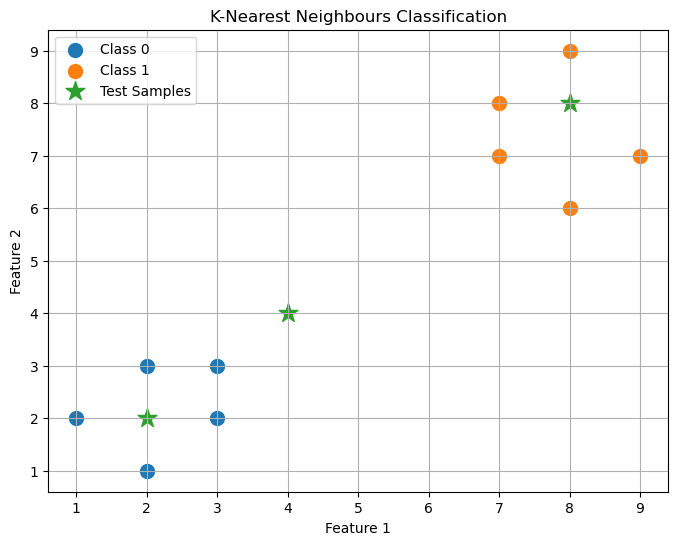

In [7]:
# ------------------------------------------------------------
# 6. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    k
)


# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------

print("Test Samples:")
print(X_test)

print("\nPredicted Classes:")
print(y_pred)


# ------------------------------------------------------------
# 8. VISUALIZE TRAINING DATA AND TEST SAMPLES
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Class 0
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    label="Class 0",
    s=100
)

# Class 1
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    label="Class 1",
    s=100
)

# Test samples
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    marker="*",
    s=200,
    label="Test Samples"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("K-Nearest Neighbours Classification")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ------------------------------------------------------------
# DETAILED KNN CALCULATION FOR ONE TEST SAMPLE
# ------------------------------------------------------------

test_point = np.array([4, 4])

k = 3

print("Test point:", test_point)
print("\nDistances from test point:\n")


# Calculate distance to every training sample
distance_list = []

for i in range(len(X_train)):

    distance = euclidean_distance(
        test_point,
        X_train[i]
    )

    distance_list.append((i, distance, y_train[i]))

    print(
        "Training point:",
        X_train[i],
        " Distance:",
        round(distance, 3),
        " Class:",
        y_train[i]
    )


# ------------------------------------------------------------
# SORT ACCORDING TO DISTANCE
# ------------------------------------------------------------

distance_list.sort(key=lambda x: x[1])

print("\nSorted distances:\n")

for item in distance_list:
    print(
        "Index:",
        item[0],
        "Distance:",
        round(item[1], 3),
        "Class:",
        item[2]
    )


# ------------------------------------------------------------
# SELECT K NEAREST NEIGHBOURS
# ------------------------------------------------------------

nearest = distance_list[:k]

print("\nK nearest neighbours:")

for item in nearest:
    print(
        "Point:",
        X_train[item[0]],
        "Distance:",
        round(item[1], 3),
        "Class:",
        item[2]
    )


# ------------------------------------------------------------
# MAJORITY VOTING
# ------------------------------------------------------------

nearest_labels = [item[2] for item in nearest]

classes, counts = np.unique(
    nearest_labels,
    return_counts=True
)

predicted_class = classes[np.argmax(counts)]

print("\nNeighbour labels:", nearest_labels)
print("Class counts:", dict(zip(classes, counts)))
print("Predicted class:", predicted_class)

Test point: [4 4]

Distances from test point:

Training point: [1 2]  Distance: 3.606  Class: 0
Training point: [2 3]  Distance: 2.236  Class: 0
Training point: [2 1]  Distance: 3.606  Class: 0
Training point: [3 2]  Distance: 2.236  Class: 0
Training point: [3 3]  Distance: 1.414  Class: 0
Training point: [7 8]  Distance: 5.0  Class: 1
Training point: [8 9]  Distance: 6.403  Class: 1
Training point: [9 7]  Distance: 5.831  Class: 1
Training point: [8 6]  Distance: 4.472  Class: 1
Training point: [7 7]  Distance: 4.243  Class: 1

Sorted distances:

Index: 4 Distance: 1.414 Class: 0
Index: 1 Distance: 2.236 Class: 0
Index: 3 Distance: 2.236 Class: 0
Index: 0 Distance: 3.606 Class: 0
Index: 2 Distance: 3.606 Class: 0
Index: 9 Distance: 4.243 Class: 1
Index: 8 Distance: 4.472 Class: 1
Index: 5 Distance: 5.0 Class: 1
Index: 7 Distance: 5.831 Class: 1
Index: 6 Distance: 6.403 Class: 1

K nearest neighbours:
Point: [3 3] Distance: 1.414 Class: 0
Point: [2 3] Distance: 2.236 Class: 0
Point: [